# Ecommerce Growth Analytics

**Dataset:** 10,000 users, 2,000 products, 10 categories, Jan 2024 to Nov 2025

**Sources:** events (behavioral tracking) and orders / order_items (actual revenue)

---

## Business Problem

The platform has 10,000 registered users but only 32.8% ever make a purchase. 72% of new users never return after their first visit. This notebook pulls together findings from all five analyses to show where users go, what they spend, and why growth is stalling.

In [1]:
from src.db import run_sql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

ub   = run_sql('../sql/user_behavior_mart.sql')
rev  = run_sql('../sql/revenue_mart.sql')
prod = run_sql('../sql/product_mart_v2.sql')
rev_buyers = rev[rev['total_orders'] > 0].copy()
buyers_ub  = ub[ub['purchase_events'] > 0].copy()
nonbuyers  = ub[ub['purchase_events'] == 0].copy()
total = len(ub)
print(f'Users: {total:,}  |  Products: {len(prod):,}  |  Buyers (orders): {len(rev_buyers):,}')

Users: 10,000  |  Products: 2,000  |  Buyers (orders): 8,635


## 1. How Buyers and Non-Buyers Behave

Non-buyers: 6,719 users (67.2%)
Buyers:     3,281 users (32.8%)

  Views           Non-buyers: 5.6   Buyers: 5.7
  Cart Adds       Non-buyers: 1.2   Buyers: 1.2
  Wishlist Adds   Non-buyers: 0.8   Buyers: 0.8
  Active Days     Non-buyers: 7.5   Buyers: 8.8


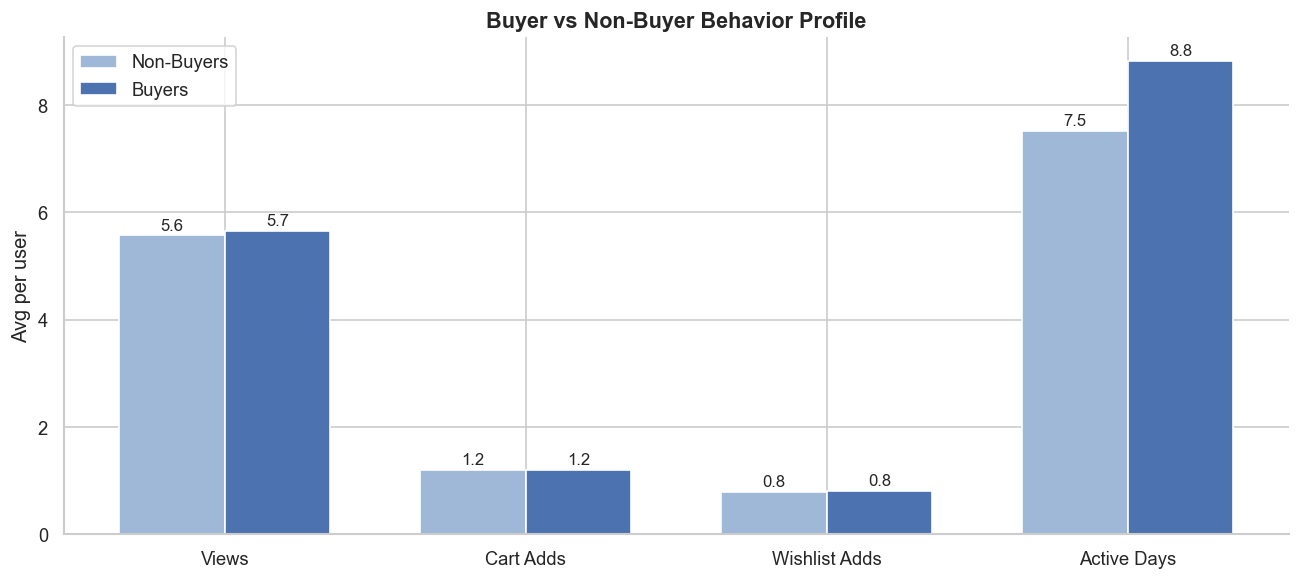

In [2]:
metrics = ['views_count', 'cart_adds', 'wishlist_adds', 'active_days']
labels  = ['Views', 'Cart Adds', 'Wishlist Adds', 'Active Days']
nb_vals = nonbuyers[metrics].mean().values
b_vals  = buyers_ub[metrics].mean().values

print(f'Non-buyers: {len(nonbuyers):,} users ({len(nonbuyers)/total*100:.1f}%)')
print(f'Buyers:     {len(buyers_ub):,} users ({len(buyers_ub)/total*100:.1f}%)')
print()
for lbl, nb_v, b_v in zip(labels, nb_vals, b_vals):
    print(f'  {lbl:<15} Non-buyers: {nb_v:.1f}   Buyers: {b_v:.1f}')

x = range(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar([i - width/2 for i in x], nb_vals, width, label='Non-Buyers', color='#9FB8D8', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], b_vals,  width, label='Buyers',     color='#4C72B0', edgecolor='white')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Buyer vs Non-Buyer Behavior Profile', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg per user')
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** Buyers and non-buyers look almost identical on every behavioral metric. Both groups average about 5.6 views, 1.2 cart adds, and 0.8 wishlist adds. Active days differ slightly: 8.8 for buyers vs 7.5 for non-buyers. This means behavioral signals alone do not separate buyers from non-buyers. The platform cannot easily predict who will convert based on how much someone browses or wishlists.

## 2. The Conversion Funnel

How many users made it to each stage, and how many dropped off at each step.

Funnel:
  Viewed           9,961  (99.6%)
  Added to Cart    6,994  (69.9%)
  Wishlisted       5,504  (55.0%)
  Purchased        3,281  (32.8%)

View to purchase: 32.9% end-to-end


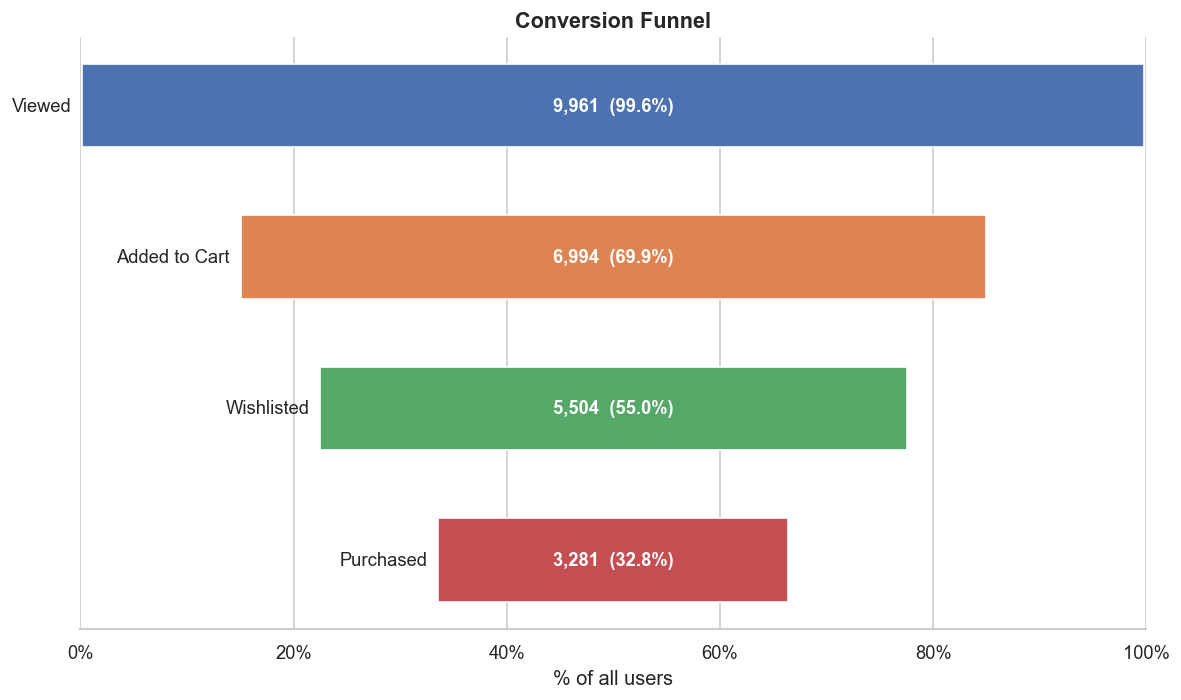

In [3]:
total   = len(ub)
viewers = (ub['views_count'] > 0).sum()
carted  = (ub['cart_adds'] > 0).sum()
wishd   = (ub['wishlist_adds'] > 0).sum()
bought  = (ub['purchase_events'] > 0).sum()

stages = ['Viewed', 'Added to Cart', 'Wishlisted', 'Purchased']
counts = [viewers, carted, wishd, bought]
pcts   = [c/total*100 for c in counts]

print('Funnel:')
for s, c, p in zip(stages, counts, pcts):
    print(f'  {s:<15} {c:>6,}  ({p:.1f}%)')
print(f'\nView to purchase: {bought/viewers*100:.1f}% end-to-end')

fig, ax = plt.subplots(figsize=(10, 6))
bar_w   = [c / total * 100 for c in counts]
offsets = [(100 - b) / 2 for b in bar_w]
colors_f = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
y_pos = range(len(stages))

for i, (stage, width_pct, offset, color, cnt) in enumerate(
        zip(stages[::-1], bar_w[::-1], offsets[::-1], colors_f[::-1], counts[::-1])):
    ax.barh(i, width_pct, left=offset, color=color, edgecolor='white', height=0.55)
    ax.text(50, i, f'{cnt:,}  ({width_pct:.1f}%)',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text(offset - 1, i, stage, ha='right', va='center', fontsize=11)

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('% of all users')
ax.set_title('Conversion Funnel', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Observation:** 99.6% of users viewed at least one product, 69.9% added to cart, 55% wishlisted. These are strong engagement numbers. 32.8% made a purchase. Each step of the funnel loses roughly 15 to 22 percentage points, which is a normal pattern for ecommerce. There is no single catastrophic drop that stands out. See `02_funnel_analysis.ipynb` for the breakdown by category.

## 3. What Sells and What Does Not

Category revenue:
  Electronics          $ 4,961,737   41.6%  avg price $852
  Automotive           $ 2,501,361   21.0%  avg price $418
  Home & Kitchen       $ 1,132,697    9.5%  avg price $194
  Sports               $   952,403    8.0%  avg price $169
  Clothing             $   710,954    6.0%  avg price $111
  Beauty               $   555,775    4.7%  avg price $88
  Toys                 $   385,483    3.2%  avg price $59
  Pet Supplies         $   354,036    3.0%  avg price $53
  Books                $   274,826    2.3%  avg price $44
  Groceries            $    89,398    0.8%  avg price $17


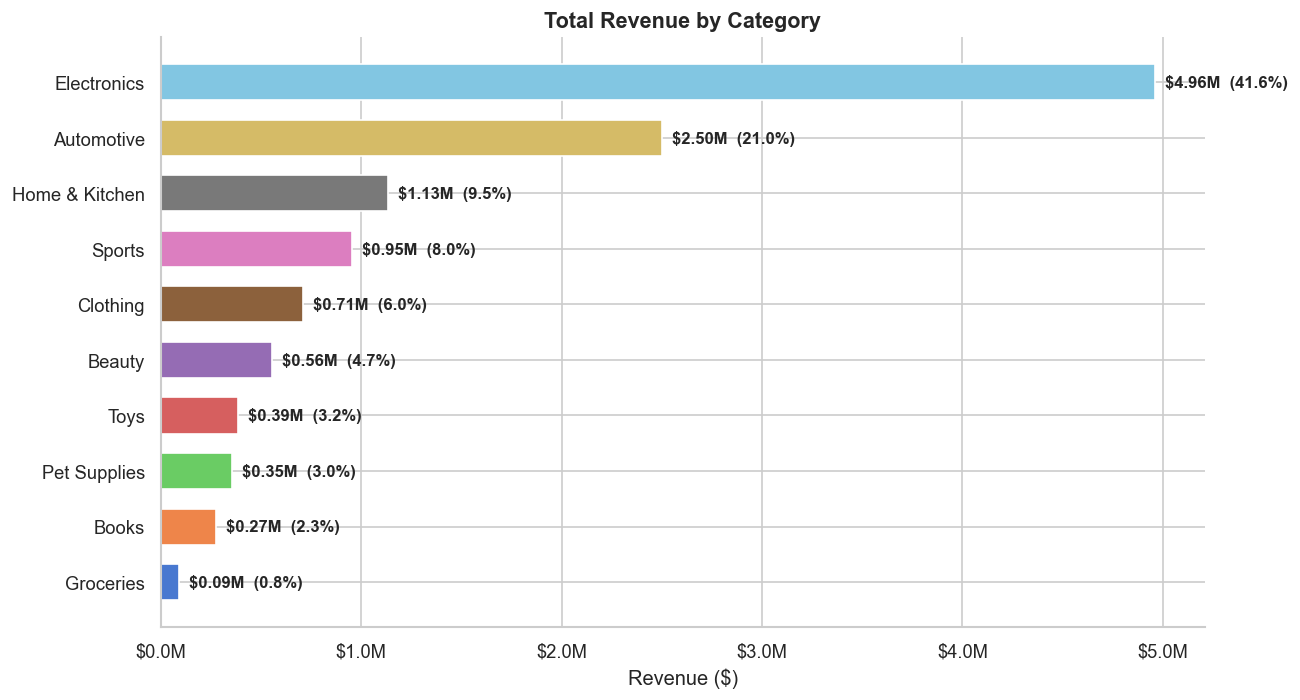

In [4]:
cat_rev = prod.groupby('category').agg(
    revenue=('revenue','sum'),
    units=('units_sold','sum'),
    avg_price=('price','mean')
).sort_values('revenue', ascending=False).round(0)
cat_rev['share'] = (cat_rev['revenue'] / cat_rev['revenue'].sum() * 100).round(1)

print('Category revenue:')
for cat, row in cat_rev.iterrows():
    print(f'  {cat:<20} ${row["revenue"]:>10,.0f}  {row["share"]:>5.1f}%  avg price ${row["avg_price"]:.0f}')

cat_sorted = cat_rev.sort_values('revenue', ascending=True)
fig, ax = plt.subplots(figsize=(11, 6))
colors_c = sns.color_palette('muted', len(cat_sorted))
bars = ax.barh(cat_sorted.index, cat_sorted['revenue'], color=colors_c, edgecolor='white', height=0.65)
for bar, (_, row) in zip(bars, cat_sorted.iterrows()):
    ax.text(bar.get_width() + cat_rev['revenue'].max()*0.01,
            bar.get_y()+bar.get_height()/2,
            f'${row["revenue"]/1e6:.2f}M  ({row["share"]}%)', va='center', fontsize=10, fontweight='bold')
ax.set_title('Total Revenue by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** Electronics accounts for 41.6% of total revenue at $4.96M. Automotive is second at $2.5M (21%). All other 8 categories share the remaining 37.4%. The gap between Electronics and everything else is driven entirely by price: Electronics products average over $1,200 per unit while most other categories are under $100. Unit sales per product are roughly equal across all categories, so price point is the main factor separating high and low revenue categories.

## 4. Who Actually Drives Revenue

One-time buyers: 2,741 (31.7%)  avg spend: $577
Repeat buyers:   5,894 (68.3%)  avg spend: $1754
Revenue from repeat buyers: $10,338,139 (86.7%)


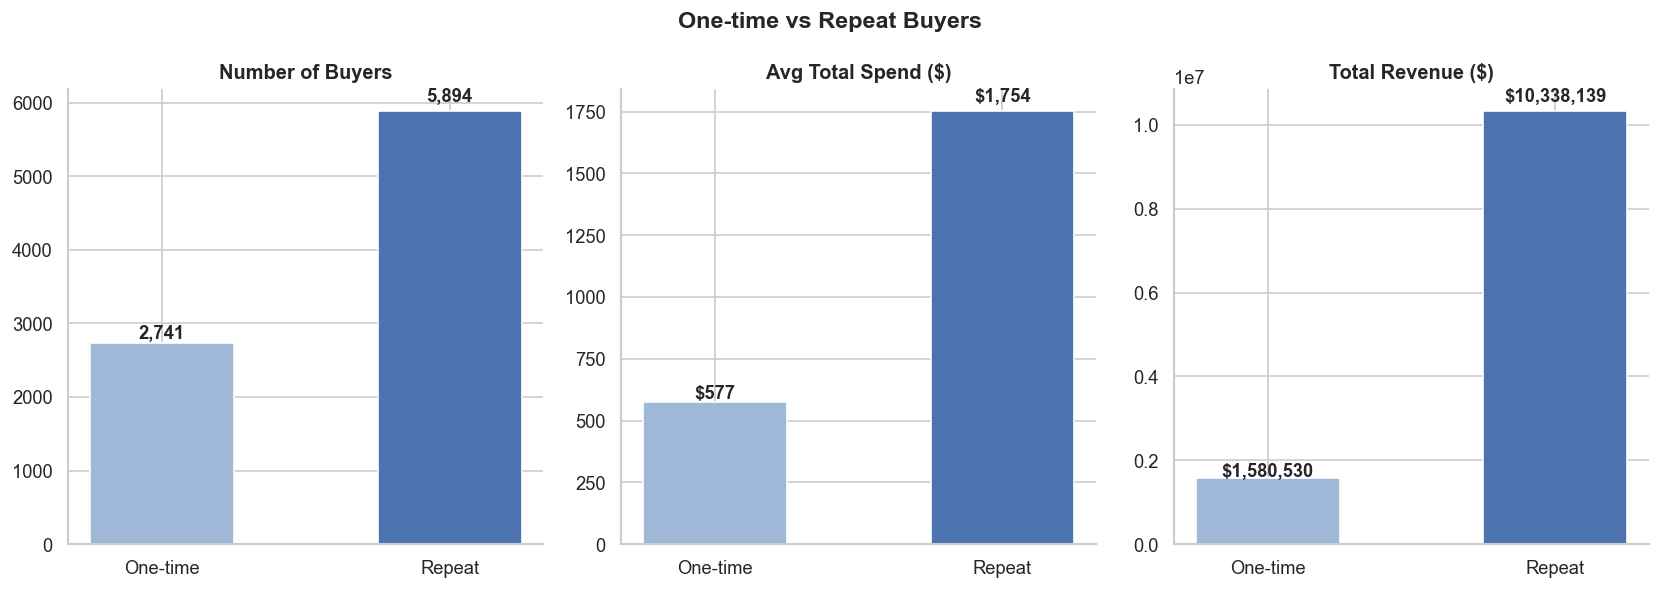

In [5]:
one_time = rev_buyers[rev_buyers['total_orders'] == 1].copy()
repeat   = rev_buyers[rev_buyers['total_orders'] > 1].copy()
total_revenue = rev_buyers['total_spent'].sum()

print(f'One-time buyers: {len(one_time):,} ({len(one_time)/len(rev_buyers)*100:.1f}%)  avg spend: ${one_time["total_spent"].mean():.0f}')
print(f'Repeat buyers:   {len(repeat):,} ({len(repeat)/len(rev_buyers)*100:.1f}%)  avg spend: ${repeat["total_spent"].mean():.0f}')
print(f'Revenue from repeat buyers: ${repeat["total_spent"].sum():,.0f} ({repeat["total_spent"].sum()/total_revenue*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors_2 = ['#9FB8D8', '#4C72B0']
labels_2 = ['One-time', 'Repeat']
vals = [[len(one_time), len(repeat)],
        [one_time['total_spent'].mean(), repeat['total_spent'].mean()],
        [one_time['total_spent'].sum(), repeat['total_spent'].sum()]]
titles = ['Number of Buyers', 'Avg Total Spend ($)', 'Total Revenue ($)']
fmts   = ['{:,.0f}', '${:,.0f}', '${:,.0f}']
for ax, v, title, fmt in zip(axes, vals, titles, fmts):
    bars = ax.bar(labels_2, v, color=colors_2, edgecolor='white', width=0.5)
    for bar, val in zip(bars, v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                fmt.format(val), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    sns.despine(ax=ax)
fig.suptitle('One-time vs Repeat Buyers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** 68.3% of buyers place more than one order and average $1,754 in total spend. One-time buyers average $577. Repeat buyers generate the large majority of revenue despite being a subset of the buyer base. See `03_revenue_analysis.ipynb` for the full breakdown.

## 5. Revenue Concentration

Top 10% of buyers  (863 people) = 33.4% of revenue
Top 20% of buyers  (1,727 people) = 53.0% of revenue
Top 50% of buyers  (4,317 people) = 85.7% of revenue


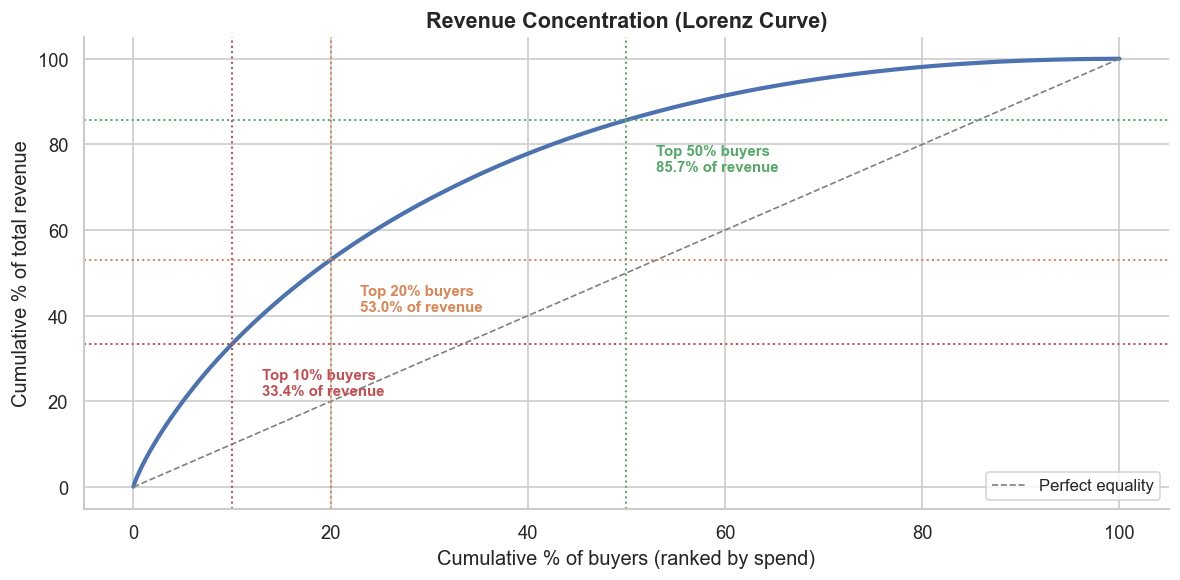

In [6]:
buyers_sorted = rev_buyers.sort_values('total_spent', ascending=False).copy()
buyers_sorted['cum_revenue'] = buyers_sorted['total_spent'].cumsum()
buyers_sorted['cum_revenue_pct'] = buyers_sorted['cum_revenue'] / total_revenue * 100
buyers_sorted['buyer_pct'] = (np.arange(1, len(buyers_sorted)+1)) / len(buyers_sorted) * 100

top10_rev = buyers_sorted.head(int(len(buyers_sorted)*0.1))['total_spent'].sum() / total_revenue * 100
top20_rev = buyers_sorted.head(int(len(buyers_sorted)*0.2))['total_spent'].sum() / total_revenue * 100
top50_rev = buyers_sorted.head(int(len(buyers_sorted)*0.5))['total_spent'].sum() / total_revenue * 100

print(f'Top 10% of buyers  ({int(len(rev_buyers)*0.1):,} people) = {top10_rev:.1f}% of revenue')
print(f'Top 20% of buyers  ({int(len(rev_buyers)*0.2):,} people) = {top20_rev:.1f}% of revenue')
print(f'Top 50% of buyers  ({int(len(rev_buyers)*0.5):,} people) = {top50_rev:.1f}% of revenue')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(buyers_sorted['buyer_pct'], buyers_sorted['cum_revenue_pct'],
        color='#4C72B0', linewidth=2.5)
ax.plot([0,100],[0,100], color='grey', linestyle='--', linewidth=1, label='Perfect equality')
for pct, rev_pct, color in [(10, top10_rev, '#C44E52'), (20, top20_rev, '#DD8452'), (50, top50_rev, '#55A868')]:
    ax.axvline(pct, color=color, linestyle=':', linewidth=1.2)
    ax.axhline(rev_pct, color=color, linestyle=':', linewidth=1.2)
    ax.annotate(f'Top {pct}% buyers\n{rev_pct:.1f}% of revenue',
                xy=(pct, rev_pct), xytext=(pct+3, rev_pct-12),
                fontsize=9, fontweight='bold', color=color)
ax.set_xlabel('Cumulative % of buyers (ranked by spend)')
ax.set_ylabel('Cumulative % of total revenue')
ax.set_title('Revenue Concentration (Lorenz Curve)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** Revenue is heavily concentrated. The top 10% of buyers (863 people) generate 33.4% of all revenue. The top 20% (1,727 people) account for 53% of revenue. Half of all buyers generate 85.7% of revenue, which means the bottom half of buyers contributes just 14.3%. The business is running on a small loyal high-spend group. Losing even a portion of the top tier would have a disproportionate impact on total revenue.

## 6. New User Acquisition Is Collapsing

This chart shows how many new users joined the platform each month. Only months with at least 6 months of follow-up data are shown.

New users per month:
  2024-01  3,030  ############################################################
  2024-02  2,024  ########################################
  2024-03  1,486  #############################
  2024-04  1,035  ####################
  2024-05    734  ##############
  2024-06    498  #########
  2024-07    392  #######
  2024-08    235  ####
  2024-09    170  ###
  2024-10    122  ##
  2024-11     75  #
  2024-12     59  #
  2025-01     40  
  2025-02     26  
  2025-03     21  
  2025-04     18  
  2025-05     12  


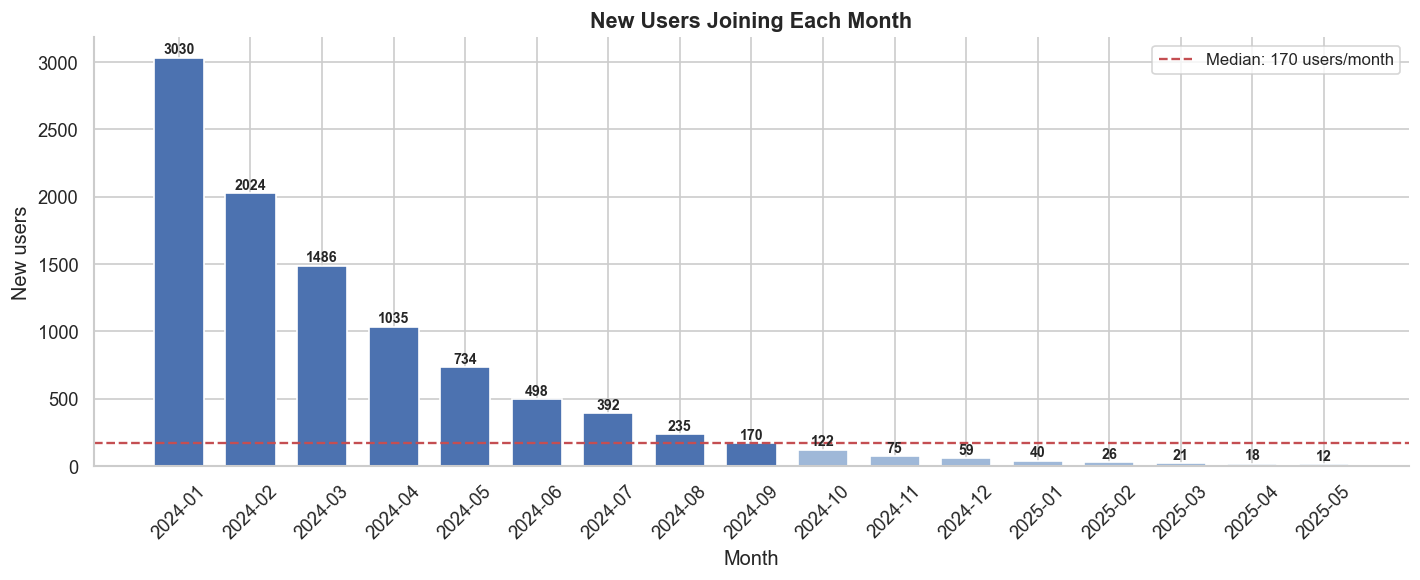

In [7]:
coh = run_sql('../sql/analysis_cohorts.sql')
coh['cohort_month'] = pd.to_datetime(coh['cohort_month'])

sizes = (coh[coh['cohort_index'] == 0]
         .groupby('cohort_month')['user_id'].nunique()
         .reset_index().rename(columns={'user_id': 'cohort_size'}))
act = (coh.groupby(['cohort_month', 'cohort_index'])['user_id']
       .nunique().reset_index().rename(columns={'user_id': 'active_users'}))
act = act.merge(sizes, on='cohort_month')
act['retention'] = (act['active_users'] / act['cohort_size'] * 100).round(1)
has6 = act[act['cohort_index'] == 5]['cohort_month'].unique()
act6 = act[act['cohort_month'].isin(has6) & (act['cohort_index'] <= 5)].copy()
sizes6 = sizes[sizes['cohort_month'].isin(has6)].copy()
sizes6['label'] = sizes6['cohort_month'].dt.strftime('%Y-%m')

print('New users per month:')
for _, row in sizes6.iterrows():
    bar = '#' * (row['cohort_size'] // 50)
    print(f'  {row["label"]}  {row["cohort_size"]:>5,}  {bar}')

fig, ax = plt.subplots(figsize=(12, 5))
colors_acq = ['#4C72B0' if s >= sizes6['cohort_size'].median() else '#9FB8D8'
              for s in sizes6['cohort_size']]
bars = ax.bar(sizes6['label'], sizes6['cohort_size'], color=colors_acq, edgecolor='white', width=0.7)
for bar, val in zip(bars, sizes6['cohort_size']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            str(val), ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.axhline(sizes6['cohort_size'].median(), color='#C44E52', linewidth=1.4,
           linestyle='--', label=f'Median: {int(sizes6["cohort_size"].median())} users/month')
ax.set_title('New Users Joining Each Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('New users')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** In January 2024 the platform acquired 3,030 new users. By June 2024 that number had dropped to 498. By December 2024 it was 59. By May 2025 only 12 new users joined. That is a 99.6% decline in monthly acquisition over 17 months. The platform is still generating revenue from its existing loyal base, but there is virtually no new user growth coming in.

## 7. Do Users Come Back?

Users are grouped by the month they first appeared. The chart shows what percentage of each group was still active in months 1 through 5.

Average return rate:
  Joined              100.0%
  1 month later       27.7%
  2 months later      28.2%
  3 months later      30.9%
  4 months later      30.1%
  5 months later      30.9%


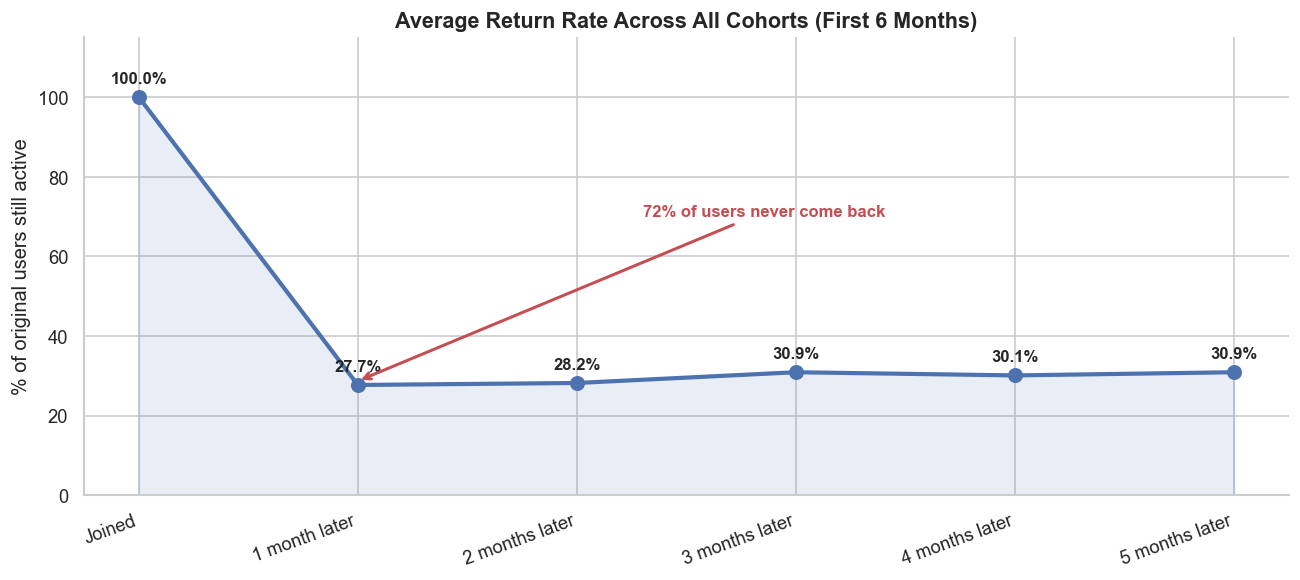

In [8]:
avg_ret = act6.groupby('cohort_index')['retention'].mean().round(1).reset_index()
avg_ret.columns = ['month_num', 'retention']
avg_ret['label'] = ['Joined', '1 month later', '2 months later',
                    '3 months later', '4 months later', '5 months later']
m0 = avg_ret.loc[0, 'retention']
m1 = avg_ret.loc[1, 'retention']

print('Average return rate:')
for _, row in avg_ret.iterrows():
    print(f'  {row["label"]:<18}  {row["retention"]:.1f}%')

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(avg_ret))
ax.plot(x, avg_ret['retention'], color='#4C72B0', linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(x, avg_ret['retention'], alpha=0.12, color='#4C72B0')
for i, row in avg_ret.iterrows():
    ax.text(i, row['retention'] + 3.5, f"{row['retention']:.1f}%",
            ha='center', fontsize=10, fontweight='bold')
ax.annotate(
    f'{m0-m1:.0f}% of users never come back',
    xy=(1, m1+1), xytext=(2.3, 70),
    fontsize=10, color='#C44E52', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.8)
)
ax.set_xticks(x)
ax.set_xticklabels(avg_ret['label'], rotation=20, ha='right')
ax.set_title('Average Return Rate Across All Cohorts (First 6 Months)', fontsize=13, fontweight='bold')
ax.set_ylabel('% of original users still active')
ax.set_ylim(0, 115)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** 72% of new users never return after their first month. This is consistent across all 17 cohorts analyzed from January 2024 through May 2025. Users who do return in month 2 stay active through months 3, 4, 5, and 6 at a stable 27 to 31%. The platform retains its core users well. The problem is that only 28% of new users ever become part of that core. See `05_cohort_analysis.ipynb` for the full per-cohort breakdown.

---

## Conclusions

**The platform has a retention problem, not a funnel problem.**
The funnel itself is working as expected: 70% add to cart, 55% wishlist, 33% purchase. Each drop is normal for ecommerce. The real issue is that 72% of new users leave after their first visit and never come back, so there is no second or third chance to capture people who did not buy on day one.

**Behavioral signals do not separate buyers from non-buyers.**
Buyers and non-buyers browse, cart, and wishlist at almost identical rates. This makes it hard to build predictive re-engagement logic based on on-site behavior alone. The conversion decision happens outside what the data currently captures.

**The business is running on a concentrated loyal base that is not growing.**
Top 10% of buyers generate 33.4% of revenue. Top 20% generate 53%. Monthly new user acquisition dropped from 3,030 in January 2024 to 12 in May 2025. The existing base is healthy but there is no meaningful pipeline of new users replacing or expanding it.

**Three focus areas:**

1. Fix acquisition. The platform cannot survive long-term at 12 new users per month. Understanding what drove the January 2024 spike and whether it can be replicated is the most urgent question.

2. Improve month-one-to-month-two return rate. Getting from 28% back to even 40% would add thousands of retained users to the active base. The product experience in the first session is where this is won or lost.

3. Protect the top 20% of buyers. They generate more than half of all revenue. Any churn in that group hits the business disproportionately hard.